# Day 39
- Mean Absolute Error(MAE)
- Mean Squared Error (MSE)
- Coefficient of Determinant (R^2)
- Maximum Likelyhood Estimation(MLE)
- Probability Mass Function.
- Binomial Distribution

In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt

data_df = pd.read_csv("https://www.statlearning.com/s/Advertising.csv")

data_df.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [2]:
X = data_df.TV.to_numpy().reshape(-1,1)
Y = data_df.sales.to_numpy().reshape(-1,1)

In [3]:
X.shape

(200, 1)

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression



In [5]:
X_train , X_test , Y_train , Y_test = train_test_split(X,Y,test_size=0.2, random_state=909)

In [6]:
X_train.shape

(160, 1)

In [7]:
X_test.shape

(40, 1)

In [8]:
Y_test.shape

(40, 1)

In [9]:
Y_train.shape

(160, 1)

In [10]:
linear_reg = LinearRegression()
linear_reg.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[0.05]]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[7.04]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[1064.21]


In [11]:
linear_reg.coef_

array([[0.04710336]])

In [12]:
linear_reg.intercept_

array([7.04206318])

In [13]:
Y_pred = linear_reg.predict(X_test)
Y_pred

array([[16.78303811],
       [17.88054641],
       [18.7425379 ],
       [20.83863744],
       [11.30020696],
       [18.31389732],
       [ 7.4377314 ],
       [20.87160979],
       [16.14243241],
       [17.74394666],
       [11.77124056],
       [17.39538179],
       [ 7.92760635],
       [16.69825206],
       [ 7.44715208],
       [17.18812701],
       [20.24042476],
       [ 8.22435752],
       [10.26393303],
       [10.72554596],
       [16.58049366],
       [18.42694539],
       [16.41092156],
       [10.19327799],
       [ 7.85224098],
       [13.59885095],
       [20.51362425],
       [ 9.07221801],
       [16.34968719],
       [13.53761658],
       [13.13723801],
       [ 7.96528904],
       [ 7.29642132],
       [12.84048684],
       [14.73404193],
       [13.77313338],
       [ 9.31715548],
       [ 7.6591172 ],
       [13.45754086],
       [14.89890369]])

In [14]:
SSE = np.sum(np.power((Y_test - Y_pred),2))

In [15]:
SSE

np.float64(350.3553922682762)

In [17]:
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score

In [18]:
mean_squared_error(Y_test,Y_pred)

8.758884806706906

In [19]:
mean_absolute_error(Y_test,Y_pred)

2.3382554545772445

In [20]:
r2_score(Y_test,Y_pred)

0.6956649384057585

In [21]:
# observed data
n = 20
k = 15


In [22]:
p_hat = k/n
print(f"Analytical MLE = {p_hat:.3f}")

Analytical MLE = 0.750


In [28]:
# Likelihood ad log-likelihood 

p = np.linspace(0.001,0.99,500)


In [29]:
likelihood = p**k * (1-p)**(n-k)
log_likelihood = k*np.log(p)+ (n-k)* np.log(1-p)
best_p = p[np.argmax(log_likelihood)]

print(f"Numeical MLE", best_p)

Numeical MLE 0.7501823647294589


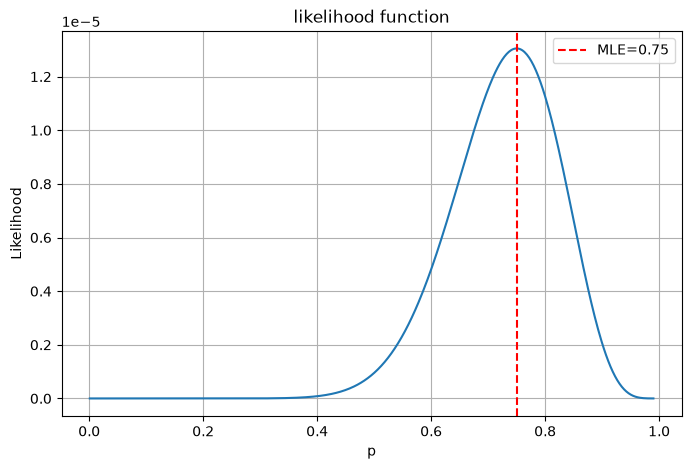

In [31]:
plt.figure(figsize=(8,5))
plt.plot(p,likelihood)
plt.axvline(best_p, color="red",linestyle = "--" , label=f"MLE={best_p:.2f}")
plt.title("likelihood function")
plt.xlabel("p")
plt.ylabel("Likelihood")
plt.grid(True)
plt.legend()
plt.show()

